# Install libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from scipy.optimize import curve_fit

# Opening cleaned PAROS dataset

In [5]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

Loaded cleaned PAROS dataset: (28665, 67)


/tmp/ipykernel_28284/1582093032.py:14: DtypeWarning: Columns (5,32,33,37,43,46,47,48,49,50,51,52,53,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLEANED_DATASET_PATH)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,ANY ROSC,Cause of arrest.1,"If 'Non-Trauma', please specify.1",Reason for discontinuing CPR at ED,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown
0,Ems,2010-04-01,470146.0,NaN,Home Residence,Hdb Level 7,60,Years,Male,Chinese,...,Yes,Non-Trauma,Respiratory,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN
1,Ems,2010-04-01,520926.0,NaN,Home Residence,Hdb Level 2,60,Years,Female,Chinese,...,No,Non-Trauma,Presumed Cardiac Etiology,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN
2,Ems,2010-04-01,560565.0,NaN,Healthcare Facility,Nkf Dialysis Centre,64,Years,Male,Chinese,...,Yes,Non-Trauma,Presumed Cardiac Etiology,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN


# Setting columns for feature engineering

In [6]:
# This will be used to calculate time to defib
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'

# This will be used to calculate into a binary status of 0/1 survival
status_col = 'Patient status'

# This will be used for CPC analysis
cpc_col = 'Patient neurological status - Cerebral'

df_survival = df.copy()
# display(df_survival[[call_time_col, shock_time_col, status_col, cpc_col]].head())

# Calculating the time to defib

In [7]:
df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
                                          format = "mixed",
                                          errors='coerce')
df_survival['Shock_Time'] = pd.to_datetime(df_survival[shock_time_col].astype(str),
                                           format='mixed',
                                           errors='coerce')

# Calculate the difference in minutes
df_survival['Time_to_Defib'] = (df_survival['Shock_Time'] - df_survival['Call_Time']).dt.total_seconds() / 60

# Fix midnight crossover overlaps
df_survival.loc[df_survival['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440

# display(df_survival[['Call_Time', 'Shock_Time', 'Time_to_Defib']].head(10))

/tmp/ipykernel_28284/1114125350.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
/tmp/ipykernel_28284/1114125350.py:4: FutureWarning: ChainedAssignmentError

Time to defib will show 13.9 minutes (standard decimal format)

Example (Index 0):
-   54 seconds ÷ 60 seconds = 0.90 minutes.
-   13 minutes + 0.90 minutes = 13.90 minutes.

# Feature Engineering for Survival Status

- 0 = Dead
- 1 = Survived

In [8]:
df_survival['Survival_Status'] = ~df_survival[status_col].astype(str).str.contains('Dead|Died',
                                                                                   case=False,
                                                                                   na=False)
df_survival['Survival_Status'] = df_survival['Survival_Status'].astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status']].head())

/tmp/ipykernel_28284/651849750.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival['Survival_Status'] = ~df_survival[status_col].astype(str).str.contains('Dead|Died',
/tmp/ipykernel_28284/651849750.py:4: FutureWarning: ChainedAss

# Feature Engineering for CPC Status

-   1 = Good (CPS 1-2)
-   0 = Bad (CPC 3-5)

In [9]:
df_survival['CPC_Status'] = df_survival[cpc_col].astype(str).str.contains('1|2',
                                                                          regex=True).astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status', 'CPC_Status']].head(10))

/tmp/ipykernel_28284/3511027977.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival['CPC_Status'] = df_survival[cpc_col].astype(str).str.contains('1|2',


# Creating a clean dataframe for analysis

-   Create 1-minute bins (0, 1, 2, 3... up to max cutoff)

In [10]:
df_clean = df_survival.dropna(subset=["Time_to_Defib", "Survival_Status", "CPC_Status"]).copy()

# Keeping response time based off the max time
max_time = 20
df_clean = df_clean[df_clean['Time_to_Defib'] <= max_time]
df_clean['Time_Bin'] = np.floor(df_clean['Time_to_Defib']).astype(int)

# display(df_clean[['Time_to_Defib', 'Time_Bin', 'Survival_Status', 'CPC_Status']].head(10))

/tmp/ipykernel_28284/3576499760.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_clean['Time_Bin'] = np.floor(df_clean['Time_to_Defib']).astype(int)


# Calculate the probability of survival for each 1-minute bin

In [11]:
survival_prob = df_clean.groupby('Time_Bin')['Survival_Status'].mean().reset_index()
survival_prob.columns = ['Time_Bin', 'EST_Probability']

# display(survival_prob.head())

# Calculate probability of a good CPC outcome for each 1-minute bin

In [12]:
# Create binary CPC column (1-2 = 1, 3-5 =0)
df_clean["CPC_Good_Binary"] = df_clean["CPC_Status"].apply(lambda x: 1 if x in [1,2] else 0)

# Calculate the probability of good CPC outcome by time bin
cpc_prob = df_clean.groupby('Time_Bin')['CPC_Good_Binary'].mean().reset_index()
cpc_prob.columns = ['Time_Bin', 'CPC_Good_Probability']

# display(cpc_prob.head())


/tmp/ipykernel_28284/3335134155.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_clean["CPC_Good_Binary"] = df_clean["CPC_Status"].apply(lambda x: 1 if x in [1,2] else 0)


# Creating Exponential Curve fitting

-   Use a standard exponential function and SciPy to find the best mathematical fit

In [13]:
def exponential_decay(t, a, b, c):
    return a * np.exp(-b * t) + c

# Fit the Overall Survival Data
popt_surv, _ = curve_fit(exponential_decay, survival_prob['Time_Bin'],
                         survival_prob['EST_Probability'],
                         bounds=(0, [1.0, 1.0, 1.0]))

# Fit the CPC Good Outcome Data
popt_cpc, _ = curve_fit(exponential_decay, cpc_prob['Time_Bin'],
                        cpc_prob['CPC_Good_Probability'],
                        bounds=(0, [1.0, 1.0, 1.0]))

# Generate X Values for plotting the fitted line
t_smooth = np.linspace(0, max_time, 100)
fitted_surv = exponential_decay(t_smooth, *popt_surv)
fitted_cpc = exponential_decay(t_smooth, *popt_cpc)

# Plotting the Visualization

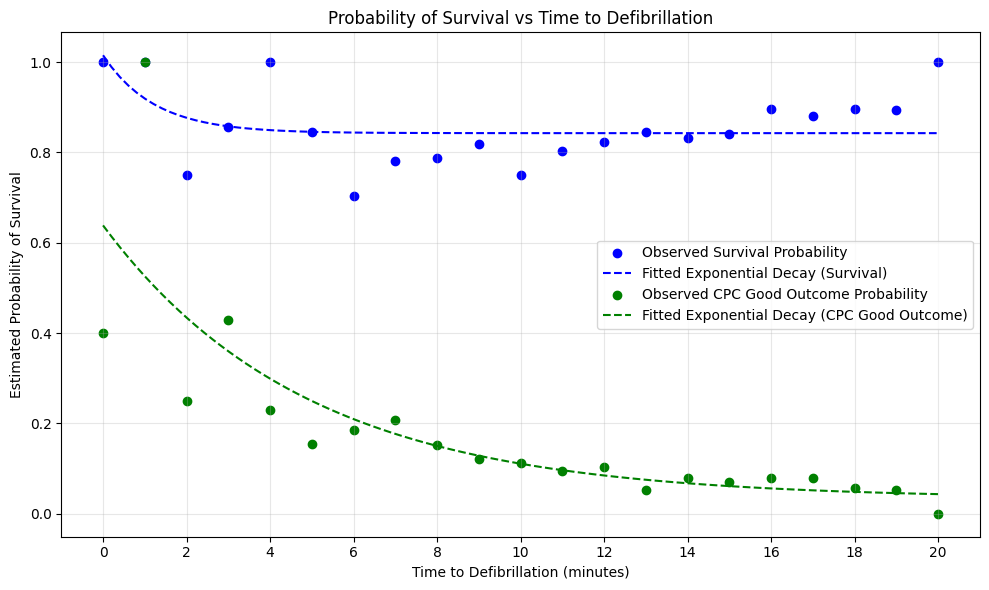

In [14]:
plt.figure(figsize=(10, 6))

# Plot Overall Survival
plt.scatter(survival_prob['Time_Bin'],
            survival_prob['EST_Probability'],
            color='blue',
            label='Observed Survival Probability')
plt.plot(t_smooth,
         fitted_surv,
         color='blue',
         linestyle='--',
         label='Fitted Exponential Decay (Survival)')

# Plot CPC Good Outcome
plt.scatter(cpc_prob['Time_Bin'],
            cpc_prob['CPC_Good_Probability'],
            color='green',
            label='Observed CPC Good Outcome Probability')
plt.plot(t_smooth,
         fitted_cpc,
         color='green',
         linestyle='--',
         label='Fitted Exponential Decay (CPC Good Outcome)')

plt.title("Probability of Survival vs Time to Defibrillation")
plt.xlabel("Time to Defibrillation (minutes)")
plt.ylabel("Estimated Probability of Survival")
plt.xticks(np.arange(0, max_time + 1, 2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()